# 01 — Baseline: features acústicos manuales

**EmotiSpeech · Parte 1 de 3** — clasificador de emociones de voz (Enojo / Feliz / Tranquilidad / Tristeza).

Este notebook es la **línea base histórica** del proyecto. Antes de usar un encoder neuronal,
intentamos clasificar la emoción con un puñado de *features acústicos clásicos* extraídos a mano:
energía, pitch (tono), brillo espectral, tasa de cruces por cero (ZCR), silencios, etc.

El objetivo no es lucirnos: es **demostrar empíricamente que estos features son insuficientes**
para separar emociones (sobre todo calma ↔ tristeza, que comparten energía baja), y así
**motivar** el salto a un encoder emocional pre-entrenado en el notebook 2.

> **Arco de los 3 notebooks**
> 1. **(este)** Features manuales → baseline débil → motiva el encoder.
> 2. Encoder emocional `audeering` + auditoría de etiquetas + localización de segmentos.
> 3. Clasificación y evaluación honesta (LOOCV honesto y leave-one-collector-out) para 2/3/4 clases.

Trabajamos sobre `outputs/reporte_filtrado_v2.csv`, que el pipeline (`scripts/filtrar_audios.py`)
ya generó: una fila por audio del dataset crudo con sus 10 métricas acústicas globales y un score
por clase. **No reextraemos audio aquí** — leemos el reporte ya calculado.

In [1]:
import os
import warnings

# El notebook se corre desde notebooks/. Subimos a la raíz del proyecto para
# que todas las rutas relativas ('outputs/...', 'data/...') funcionen igual que
# en los scripts.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

REPORTE = "outputs/reporte_filtrado_v2.csv"
# Features acústicos manuales que produjo filtrar_audios.py (10 métricas globales por audio).
FEATURES = [
    "pitch_mean_st", "pitch_std_st", "pitch_range_st",
    "energy_cv", "energy_level_db", "dynamic_range_db",
    "onset_rate", "zcr_mean", "frac_silencio", "centroid_hz",
]
print("cwd:", os.getcwd())
print("¿existe el reporte?", os.path.exists(REPORTE))

cwd: /Users/apple/Desktop/Universidad/Machine Learning/clasificador-audios
¿existe el reporte? True


## 1. Carga y EDA del dataset

Cada audio fue recolectado por una de 5 personas (prefijo `MT` / `VA` / `ED` / `VZ` / `SG` en el
nombre de archivo) y etiquetado con una de las 4 emociones. El dataset es **fuertemente
desbalanceado** (mucha Tranquilidad, poco Enojo/Feliz), algo que arrastraremos en los 3 notebooks
y que compensaremos con `class_weight='balanced'` en los clasificadores.

In [2]:
df = pd.read_csv(REPORTE)
print("Audios en el reporte:", len(df))
print("\nDistribución por clase (clase_original):")
print(df["clase_original"].value_counts())
print("\nRecolectores:")
print(df["recolector"].value_counts().to_dict())
df[["archivo", "clase_original", "recolector"] + FEATURES].head()

Audios en el reporte: 152

Distribución por clase (clase_original):
clase_original
Tranquilidad    89
Tristeza        33
Enojo           17
Feliz           13
Name: count, dtype: int64

Recolectores:
{'VA': 41, 'VZ': 36, 'MT': 33, 'SG': 23, 'ED': 19}


,archivo,clase_original,recolector,pitch_mean_st,pitch_std_st,pitch_range_st,energy_cv,energy_level_db,dynamic_range_db,onset_rate,zcr_mean,frac_silencio,centroid_hz
0,ED_01_ENO_S.ogg,Enojo,ED,11.823229,6.662872,20.529961,0.700474,-22.881804,27.465567,5.335365,0.073893,0.231481,1283.588724
1,ED_01_FEL.ogg,Enojo,ED,12.037574,6.124501,21.260650,0.774769,-25.890947,48.691620,4.881704,0.083826,0.212963,1284.044616
2,ED_02_ENO_S.ogg,Enojo,ED,12.705294,5.777561,20.017477,0.808578,-23.030735,36.620159,4.008929,0.094650,0.250000,1502.338772
3,ED_03_ENO_S.ogg,Enojo,ED,18.335526,8.053389,27.447895,0.812258,-27.055960,50.767899,5.264964,0.144418,0.277778,2352.974337
4,ED_04_ENO_S.ogg,Enojo,ED,16.743108,7.546051,26.363269,0.891271,-27.229746,54.186123,5.730781,0.112517,0.333333,1769.806175


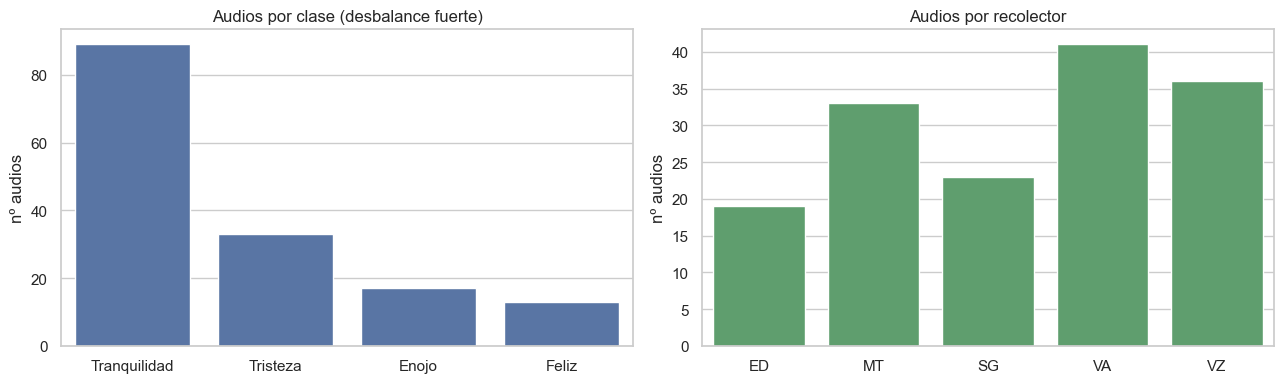

In [3]:
# Distribución de clases y de recolectores: contexto del desbalance.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
orden = df["clase_original"].value_counts().index
sns.countplot(data=df, x="clase_original", order=orden, ax=axes[0], color="#4C72B0")
axes[0].set_title("Audios por clase (desbalance fuerte)")
axes[0].set_xlabel(""); axes[0].set_ylabel("nº audios")

sns.countplot(data=df, x="recolector", ax=axes[1], color="#55A868")
axes[1].set_title("Audios por recolector")
axes[1].set_xlabel(""); axes[1].set_ylabel("nº audios")
plt.tight_layout(); plt.show()

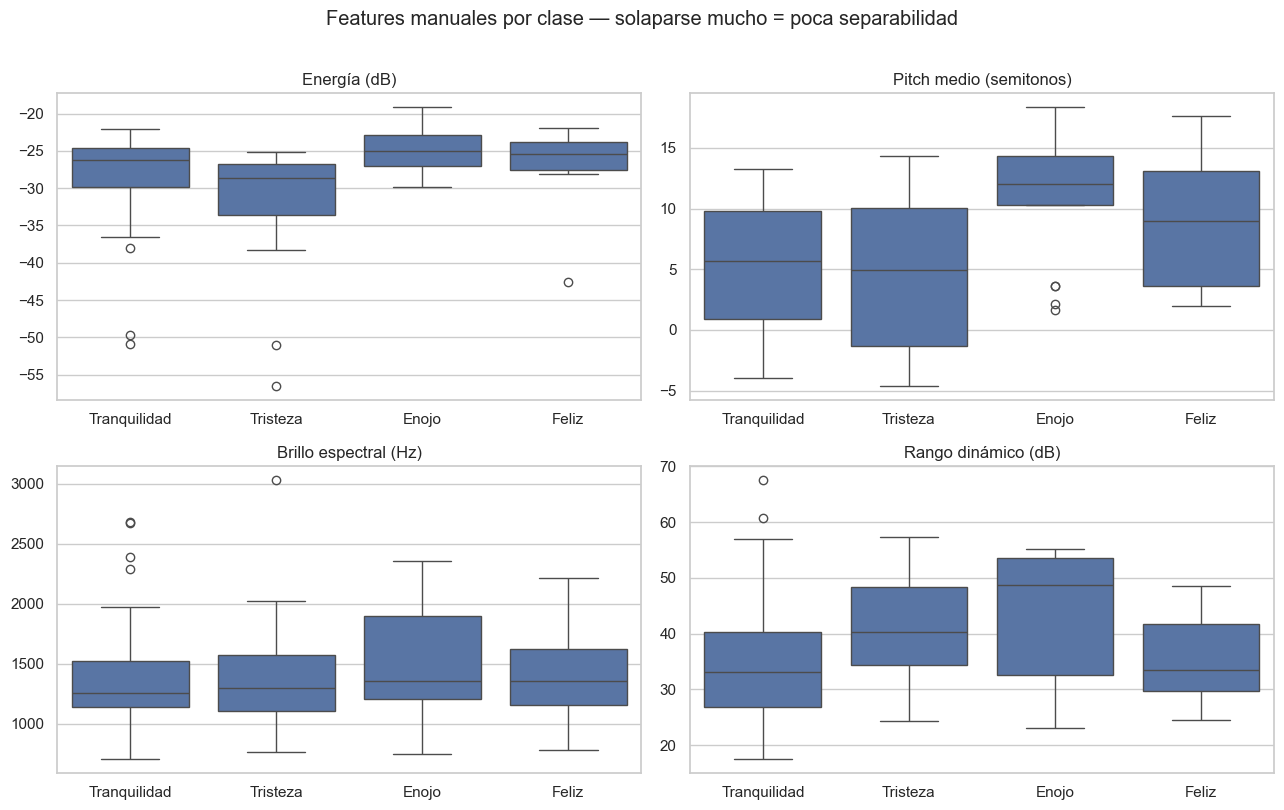

In [4]:
# ¿Separan los features acústicos a las clases? Boxplots de las métricas más
# "intuitivas" para emoción: energía, pitch, brillo, dinámica.
claves = ["energy_level_db", "pitch_mean_st", "centroid_hz", "dynamic_range_db"]
titulos = ["Energía (dB)", "Pitch medio (semitonos)", "Brillo espectral (Hz)", "Rango dinámico (dB)"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, tit in zip(axes.ravel(), claves, titulos):
    sns.boxplot(data=df, x="clase_original", y=col, ax=ax, order=orden)
    ax.set_title(tit); ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Features manuales por clase — solaparse mucho = poca separabilidad", y=1.01)
plt.tight_layout(); plt.show()

**Lectura de los boxplots:** Enojo se separa algo en energía/brillo (es la emoción más "alta"),
pero **Tranquilidad y Tristeza se solapan casi por completo**: ambas son de baja energía y pitch
moderado. Ningún feature global las distingue, porque la diferencia entre calma y tristeza está en
la *prosodia fina* (entonación, micro-tensión, ritmo) que estas 10 métricas promediadas no capturan.

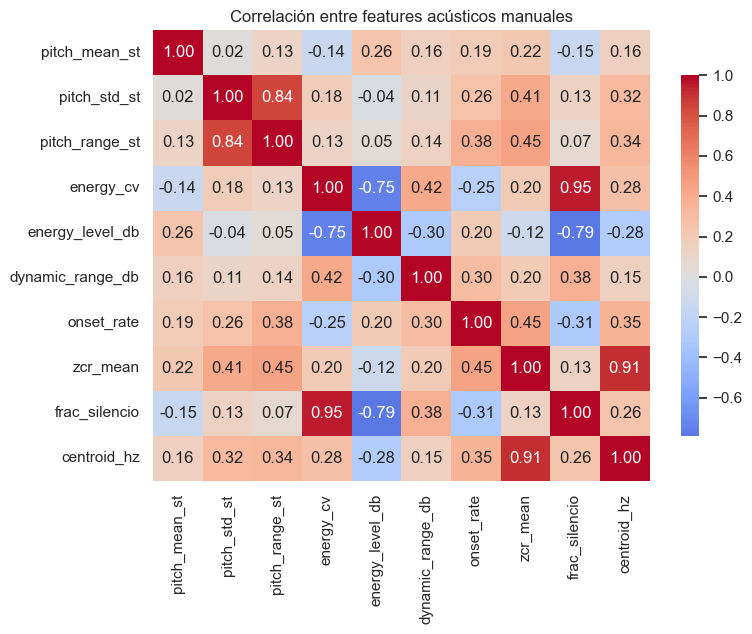

In [5]:
# Mapa de correlación de los features (¿hay redundancia?).
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlación entre features acústicos manuales")
plt.tight_layout(); plt.show()

## 2. LOOCV con features manuales (2 / 3 / 4 clases)

Evaluamos con **Leave-One-Out Cross-Validation (LOOCV)**: dejamos un audio fuera, entrenamos con
el resto y predecimos el que falta; repetimos para todos. Reportamos *balanced accuracy* (bal_acc)
para no premiar al modelo por acertar siempre la clase mayoritaria (Tranquilidad).

Usamos exactamente los **6 modelos canónicos del proyecto** (`MODEL_SPECS` en
`scripts/exportar_modelos.py`), para que la comparación contra los embeddings del notebook 3 sea
limpia: misma pipeline, sólo cambia el espacio de features (10 métricas manuales vs 1024
dimensiones emocionales).

In [6]:
import sys
sys.path.insert(0, ".")
sys.path.insert(0, "scripts")
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score

# Los 6 clasificadores canónicos (StandardScaler + class_weight='balanced' donde aplica).
from exportar_modelos import MODEL_SPECS

def loocv_balacc(builder, X, y):
    loo = LeaveOneOut()
    y_pred = np.empty(len(y), dtype=object)
    for train_idx, test_idx in loo.split(X):
        i = test_idx[0]
        pipe = builder()
        pipe.fit(X[train_idx], y[train_idx])
        y_pred[i] = pipe.predict(X[i].reshape(1, -1))[0]
    return balanced_accuracy_score(y, y_pred), y_pred

ESCENARIOS = {
    "2 clases (Enojo/Tranquilidad)": ["Enojo", "Tranquilidad"],
    "3 clases (Enojo/Feliz/Tristeza)": ["Enojo", "Feliz", "Tristeza"],
    "4 clases (todas)": ["Enojo", "Feliz", "Tranquilidad", "Tristeza"],
}

filas = []
for nombre, clases in ESCENARIOS.items():
    sub = df[df["clase_original"].isin(clases)]
    X = sub[FEATURES].values.astype(float)
    y = sub["clase_original"].values
    chance = 1.0 / len(clases)
    for key, spec in MODEL_SPECS.items():
        bal, _ = loocv_balacc(spec["builder"], X, y)
        filas.append({"escenario": nombre, "modelo": spec["label"],
                      "bal_acc": round(bal, 3), "chance": round(chance, 3)})

res_manual = pd.DataFrame(filas)
tabla = res_manual.pivot(index="modelo", columns="escenario", values="bal_acc")
tabla = tabla.reindex([s["label"] for s in MODEL_SPECS.values()])
print("Balanced accuracy LOOCV — features acústicos manuales\n")
print(tabla.to_string())
print("\nChance:", {n: round(1/len(c), 3) for n, c in ESCENARIOS.items()})

Balanced accuracy LOOCV — features acústicos manuales

escenario       2 clases (Enojo/Tranquilidad)  3 clases (Enojo/Feliz/Tristeza)  4 clases (todas)
modelo                                                                                          
SVM lineal                              0.770                            0.617             0.464
Reg. Logística                          0.787                            0.530             0.421
SVM RBF                                 0.749                            0.526             0.391
Random Forest                           0.689                            0.641             0.382
KNN (k=5)                               0.601                            0.549             0.339
KNN (k=3)                               0.590                            0.530             0.339

Chance: {'2 clases (Enojo/Tranquilidad)': 0.5, '3 clases (Enojo/Feliz/Tristeza)': 0.333, '4 clases (todas)': 0.25}


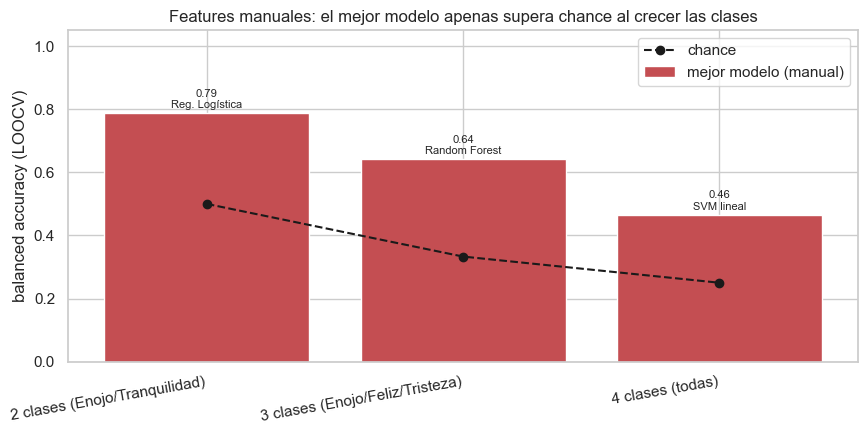

,modelo,bal_acc,chance
escenario,,,
2 clases (Enojo/Tranquilidad),Reg. Logística,0.787,0.500
3 clases (Enojo/Feliz/Tristeza),Random Forest,0.641,0.333
4 clases (todas),SVM lineal,0.464,0.250


In [7]:
# Mejor modelo por escenario vs chance.
fig, ax = plt.subplots(figsize=(9, 4.5))
best_por_esc = res_manual.loc[res_manual.groupby("escenario")["bal_acc"].idxmax()]
best_por_esc = best_por_esc.set_index("escenario").reindex(list(ESCENARIOS.keys()))
x = np.arange(len(best_por_esc))
ax.bar(x, best_por_esc["bal_acc"], color="#C44E52", label="mejor modelo (manual)")
ax.plot(x, best_por_esc["chance"], "k--o", label="chance")
for i, (b, m) in enumerate(zip(best_por_esc["bal_acc"], best_por_esc["modelo"])):
    ax.text(i, b + 0.01, f"{b:.2f}\n{m}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(best_por_esc.index, rotation=10, ha="right")
ax.set_ylabel("balanced accuracy (LOOCV)"); ax.set_ylim(0, 1.05)
ax.set_title("Features manuales: el mejor modelo apenas supera chance al crecer las clases")
ax.legend(); plt.tight_layout(); plt.show()
best_por_esc[["modelo", "bal_acc", "chance"]]

## 3. Diagnóstico de errores: ¿dónde se rompe?

Veamos la matriz de confusión del mejor modelo en el caso de 3 clases para confirmar la sospecha
de los boxplots: las confusiones se concentran donde la prosodia importa.

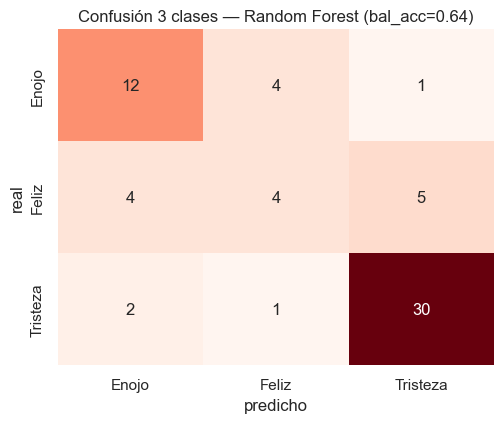

In [8]:
from sklearn.metrics import confusion_matrix

clases3 = ["Enojo", "Feliz", "Tristeza"]
sub = df[df["clase_original"].isin(clases3)]
X = sub[FEATURES].values.astype(float); y = sub["clase_original"].values

# Elegimos el mejor modelo manual en 3 clases según la tabla anterior.
sub_res = res_manual[res_manual["escenario"] == "3 clases (Enojo/Feliz/Tristeza)"]
best_label = sub_res.loc[sub_res["bal_acc"].idxmax(), "modelo"]
best_key = next(k for k, s in MODEL_SPECS.items() if s["label"] == best_label)
bal, y_pred = loocv_balacc(MODEL_SPECS[best_key]["builder"], X, y)

cm = confusion_matrix(y, y_pred, labels=clases3)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=clases3,
            yticklabels=clases3, ax=ax, cbar=False)
ax.set_xlabel("predicho"); ax.set_ylabel("real")
ax.set_title(f"Confusión 3 clases — {best_label} (bal_acc={bal:.2f})")
plt.tight_layout(); plt.show()

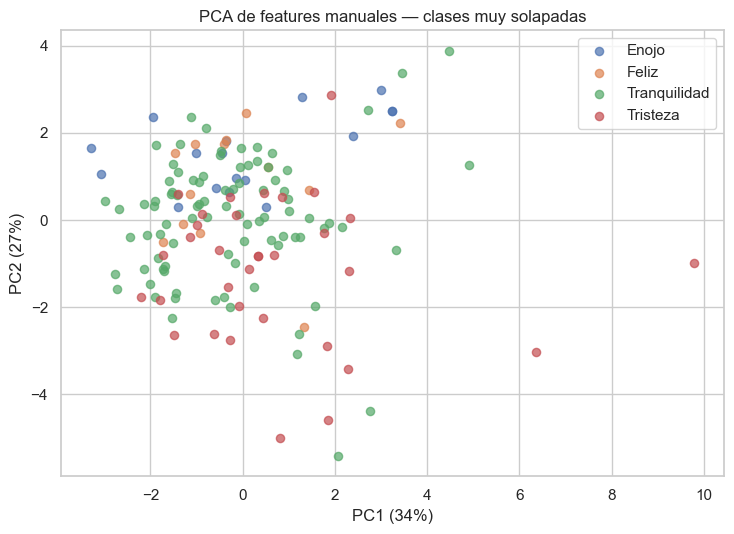

In [9]:
# Proyección PCA 2D del espacio de features manuales (4 clases): si las nubes se
# pisan, ningún clasificador lineal va a separarlas.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_all = StandardScaler().fit_transform(df[FEATURES].values.astype(float))
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_all)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for clase in ["Enojo", "Feliz", "Tranquilidad", "Tristeza"]:
    m = df["clase_original"].values == clase
    ax.scatter(proj[m, 0], proj[m, 1], label=clase, alpha=0.7, s=35)
var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var[0]*100:.0f}%)"); ax.set_ylabel(f"PC2 ({var[1]*100:.0f}%)")
ax.set_title("PCA de features manuales — clases muy solapadas")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Conclusión del baseline

- Con **2 clases** (Enojo vs Tranquilidad, las dos emociones acústicamente más opuestas) los
  features manuales *casi* funcionan: bal_acc ≈ 0.79. Enojo tiene energía y brillo claramente
  más altos.
- Al pasar a **3 y 4 clases** el rendimiento **se desploma**: con las 4 clases el mejor modelo
  cae a ~0.46 bal_acc (chance = 0.25, pero apenas por encima de acertar siempre la mayoritaria).
  La PCA lo confirma: las nubes se solapan.
- El cuello de botella es **calma ↔ tristeza** (y en parte Feliz): comparten energía baja; la
  diferencia está en la prosodia fina, invisible para 10 métricas globales promediadas.

**Moraleja:** los descriptores acústicos hechos a mano no codifican emoción, codifican *acústica*.
Necesitamos una representación que ya "sepa" de emoción.

➡️ En el **notebook 2** reemplazamos estos 10 números por los **1024 embeddings emocionales** del
encoder `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim`, fine-tuneado para
arousal/valence/dominance. En el **notebook 3** mostramos que con ese espacio el mismo LOOCV salta
de ~0.46 a ~0.86 en 4 clases.